# **Build Explainable Risk Prediction for Patient Readmission**

In [121]:
import pandas as pd
import numpy as np
import re
df = pd.read_csv(r'C:\Users\Admin\Documents\diabetic_data.csv',encoding='utf-8')

## Target defining

In [123]:

# 30 gündən tez qayıdanlar bizim üçün YÜKSƏK RİSKDİR (1)
# Digərləri isə risksizdir (0)
df['target'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Köhnə sütunu artıq silə bilərik
df = df.drop('readmitted', axis=1)

In [125]:
print(df['target'].value_counts())
print(df.shape)
df


target
0    90409
1    11357
Name: count, dtype: int64
(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,0
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,0
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,0
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,0


## Future Engineering

In [129]:
#AUC score artirmaq ucun 
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df['med_per_day'] = df['num_medications'] / (df['time_in_hospital'] + 1)
df['lab_per_day'] = df['num_lab_procedures'] / (df['time_in_hospital'] + 1)
df['repeat_admit'] = (df['number_inpatient'] > 1).astype(int)

## Encoding and Filling

In [132]:

df.replace('?', np.nan, inplace=True)

# Yaş encoding
age_id = {'[0-10)':5, '[10-20)':15, '[20-30)':25, '[30-40)':35, '[40-50)':45, 
          '[50-60)':55, '[60-70)':65, '[70-80)':75, '[80-90)':85, '[90-100)':95}
df['age'] = df['age'].map(age_id)
df['age'] = df['age'].fillna(df['age'].median())

# Null doldurma
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].median())

# Label Encoding
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [c for c in categorical_cols if c != 'target']

for col in categorical_cols:
    df[col] = df[col].astype(str)
    enc = LabelEncoder()
    df[col] = enc.fit_transform(df[col])
    label_encoders[col] = enc

## Data Training

In [134]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# X və y ayır
X = df.drop('target', axis=1)
y = df['target']

# Train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

# Class imbalance üçün weight
neg, pos = np.bincount(y_train)
spw = neg / pos
print(f"scale_cekisi: {spw:.2f}")


# Model
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42
)

model.fit(X_train, y_train)

Train: (81412, 53)
Test:  (20354, 53)
scale_cekisi: 7.96


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

## XGBoost Model AUC

In [140]:
from sklearn.metrics import roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")


AUC: 0.6904


## **Shap Model**

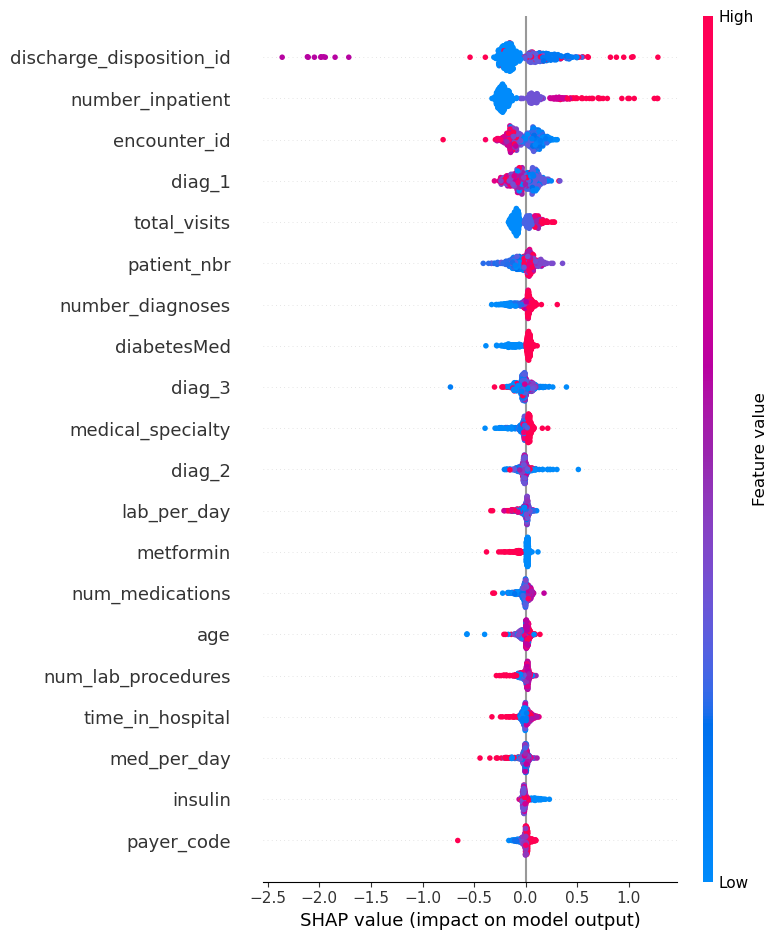

In [148]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:500])

# Global feature importance
shap.summary_plot(shap_values, X_test[:500], 
                  feature_names=X_test.columns.tolist())


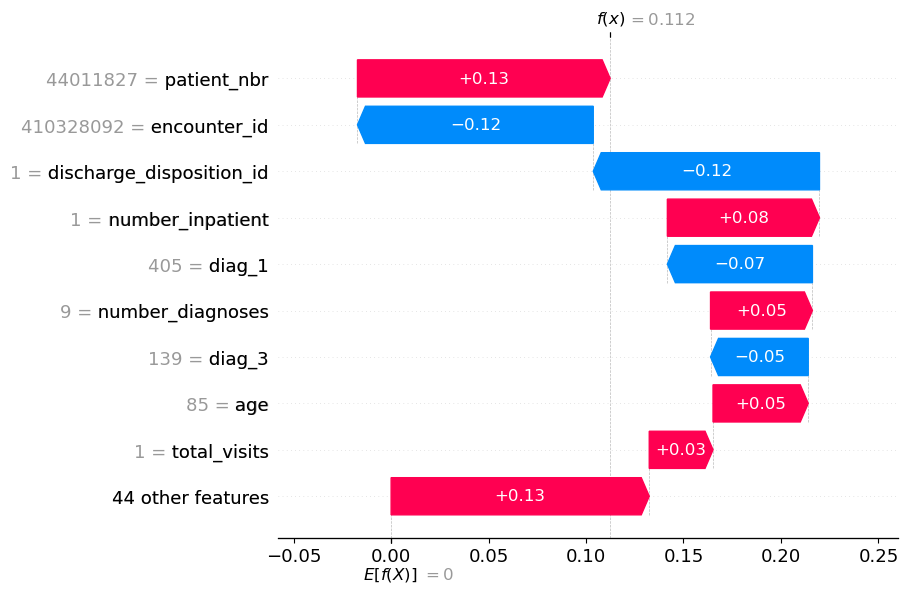

In [149]:
#tek xeste 
# 0-cı xəstəni izah et
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns.tolist()
    )
)

## **Shap Model**

In [155]:
import lime
import lime.lime_tabular

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Qayıtmadı', 'Qayıtdı'],
    mode='classification'
)

# 0-cı xəstəni izah et
exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[0].values,
    predict_fn=model.predict_proba,
    num_features=10
)

exp.show_in_notebook()

## TOP xesteler ve PDF (bonus)

In [159]:
# Bütün xəstələr üçün risk ehtimalı
X_test_copy = X_test.copy()
X_test_copy['risk_prob'] = model.predict_proba(X_test)[:, 1]
X_test_copy['actual'] = y_test.values

# top 10 xəstə
top10 = X_test_copy.nlargest(10, 'risk_prob')[['risk_prob', 'actual']]
print(top10)

       risk_prob  actual
88392   0.930485       0
26412   0.928357       1
49759   0.921660       0
94885   0.921605       1
61923   0.920320       0
62759   0.917520       1
75933   0.916403       1
85338   0.914205       1
53302   0.911800       1
58295   0.911021       1


In [161]:
pip install reportlab

Note: you may need to restart the kernel to use updated packages.


In [163]:
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet
from datetime import datetime

def generate_report(patient_idx, probability, lime_exp):
    path = f'patient_{patient_idx}_report.pdf'
    doc = SimpleDocTemplate(path, pagesize=A4)
    styles = getSampleStyleSheet()
    story = []

    # Başlıq
    story.append(Paragraph('Xəstə Yenidən Qəbul Riski Hesabatı', styles['Title']))
    story.append(Spacer(1, 12))

    # Risk səviyyəsi
    level = 'YÜKSƏK RİSK' if probability >= 0.45 else 'AŞAĞI RİSK'
    story.append(Paragraph(f'Risk Ehtimalı: {probability:.1%} — {level}', styles['Heading2']))
    story.append(Spacer(1, 12))

    # LIME qaydaları
    story.append(Paragraph('LIME İzahı:', styles['Heading3']))
    for rule, val in lime_exp.as_list():
        color = '🔴' if val > 0 else '🔵'
        story.append(Paragraph(f'{color} {rule} → {val:.3f}', styles['Normal']))

    # Tarix
    story.append(Spacer(1, 20))
    story.append(Paragraph(f'Tarix: {datetime.now().strftime("%Y-%m-%d %H:%M")}', styles['Normal']))

    doc.build(story)
    print(f'PDF → {path}')

# 0-cı xəstə üçün report yarat
prob = model.predict_proba(X_test.iloc[[0]])[0, 1]
exp = explainer_lime.explain_instance(
    data_row=X_test.iloc[0].values,
    predict_fn=model.predict_proba,
    num_features=10
)
generate_report(0, prob, exp)

PDF → patient_0_report.pdf
